<a href="https://colab.research.google.com/github/AngieVenta/AngieVenta/blob/main/Solucion_Reto_SC_63_GloriaAngelicaVenta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto | Mercadotecnia Telefónica con Aprendizaje Supervisado

## Objetivo
Diseñar e implementar modelos de aprendizaje supervisado (Regresión Logística y Red Neuronal) para predecir si un cliente suscribirá un **depósito a plazo** (*term deposit*) a través de una campaña de telemarketing bancario.


In [67]:
# Librerías generales
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Evaluación
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 2. Carga de datos

In [68]:
# Carga del dataset en 'data'
data = pd.read_csv('bank_marketing_RETO_DS_AS.csv')

print(f'Dataset cargado exitosamente.')
print(f'Dimensiones: {data.shape[0]} registros x {data.shape[1]} variables')
data.head(10)

Dataset cargado exitosamente.
Dimensiones: 9000 registros x 17 variables


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,31,self-employed,married,tertiary,no,2666,no,no,cellular,10,nov,318,2,97,6,success,yes
1,29,unemployed,single,unknown,no,1584,no,no,cellular,6,sep,245,1,-1,0,unknown,yes
2,41,blue-collar,married,secondary,no,2152,yes,no,cellular,17,nov,369,1,-1,0,unknown,no
3,50,blue-collar,married,secondary,no,84,yes,no,cellular,17,jul,18,8,-1,0,unknown,no
4,40,admin.,married,secondary,no,0,no,no,cellular,28,jul,496,2,182,11,success,yes
5,58,retired,married,secondary,no,8332,no,no,cellular,13,aug,740,4,-1,0,unknown,no
6,36,services,single,secondary,no,198,yes,no,cellular,11,may,496,1,-1,0,unknown,no
7,26,technician,single,secondary,no,1231,yes,no,cellular,3,jun,385,2,96,5,success,yes
8,34,blue-collar,married,primary,no,2320,yes,no,cellular,18,nov,63,1,-1,0,unknown,no
9,26,management,single,tertiary,no,47,yes,no,cellular,18,may,63,1,-1,0,unknown,no


## 3. Análisis Descriptivo

> **Contexto:** Los datos provienen de campañas de marketing directo.. El objetivo es predecir si el cliente suscribirá un **depósito a plazo bancario** (`y = yes/no`). En muchos casos se realizaron múltiples llamadas al mismo cliente.

In [69]:
# Número de registros y variables
n_registros, n_variables = data.shape
print(f'Número de registros: {n_registros}')
print(f'Número de variables: {n_variables}')
print()
print(data.info())

# Tipo de cada variable
print('Tipo de cada variable:')
print(data.dtypes)
print()

# Variables numéricas vs categóricas
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = data.select_dtypes(include=['object']).columns.tolist()

print(f'Variables numéricas ({len(num_cols)}): {num_cols}')
print(f'Variables categóricas ({len(cat_cols)}): {cat_cols}')

Número de registros: 9000
Número de variables: 17

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        9000 non-null   int64 
 1   job        9000 non-null   object
 2   marital    9000 non-null   object
 3   education  9000 non-null   object
 4   default    9000 non-null   object
 5   balance    9000 non-null   int64 
 6   housing    9000 non-null   object
 7   loan       9000 non-null   object
 8   contact    9000 non-null   object
 9   day        9000 non-null   int64 
 10  month      9000 non-null   object
 11  duration   9000 non-null   int64 
 12  campaign   9000 non-null   int64 
 13  pdays      9000 non-null   int64 
 14  previous   9000 non-null   int64 
 15  poutcome   9000 non-null   object
 16  y          9000 non-null   object
dtypes: int64(7), object(10)
memory usage: 1.2+ MB
None
Tipo de cada variable:
age           int64
jo

In [70]:
# Datos perdidos
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_df = pd.DataFrame({'Nulos': missing, 'Porcentaje (%)': missing_pct})
print('Datos perdidos por variable:')
print(missing_df)
print()
print(f'Total de valores nulos en el dataset: {missing.sum()}')

Datos perdidos por variable:
           Nulos  Porcentaje (%)
age            0             0.0
job            0             0.0
marital        0             0.0
education      0             0.0
default        0             0.0
balance        0             0.0
housing        0             0.0
loan           0             0.0
contact        0             0.0
day            0             0.0
month          0             0.0
duration       0             0.0
campaign       0             0.0
pdays          0             0.0
previous       0             0.0
poutcome       0             0.0
y              0             0.0

Total de valores nulos en el dataset: 0


In [71]:
# Estadísticas descriptivas de variables numéricas
print('Estadísticas descriptivas — Variables numéricas:')
data[num_cols].describe().round(2)

Estadísticas descriptivas — Variables numéricas:


,age,balance,day,duration,campaign,pdays,previous
count,9000.00,9000.00,9000.00,9000.00,9000.00,9000.00,9000.00
mean,41.09,1482.26,15.62,353.83,2.52,50.51,0.79
std,11.66,3031.01,8.35,336.95,2.74,107.69,2.21
min,18.00,-3058.00,1.00,3.00,1.00,-1.00,0.00
25%,32.00,109.00,8.00,131.00,1.00,-1.00,0.00
50%,39.00,519.00,15.00,240.50,2.00,-1.00,0.00
75%,49.00,1646.50,21.00,462.00,3.00,-1.00,0.00
max,95.00,81204.00,31.00,3253.00,58.00,850.00,58.00


Distribución de la variable objetivo y:
y
no     5213
yes    3787
Name: count, dtype: int64

y
no     57.92 %
yes    42.08 %
Name: proportion, dtype: object


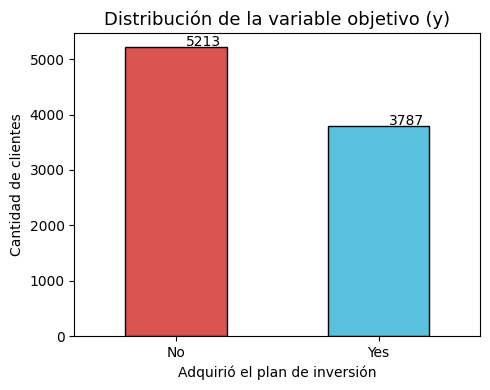

In [72]:
# Distribución de la variable objetivo 'y'
print('Distribución de la variable objetivo y:')
print(data['y'].value_counts())
print()
print(data['y'].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

fig, ax = plt.subplots(figsize=(5, 4))
data['y'].value_counts().plot(kind='bar', ax=ax, color=['#d9534f', '#5bc0de'], edgecolor='black')
ax.set_title('Distribución de la variable objetivo (y)', fontsize=13)
ax.set_xlabel('Adquirió el plan de inversión')
ax.set_ylabel('Cantidad de clientes')
ax.set_xticklabels(['No', 'Yes'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 30))
plt.tight_layout()
plt.show()

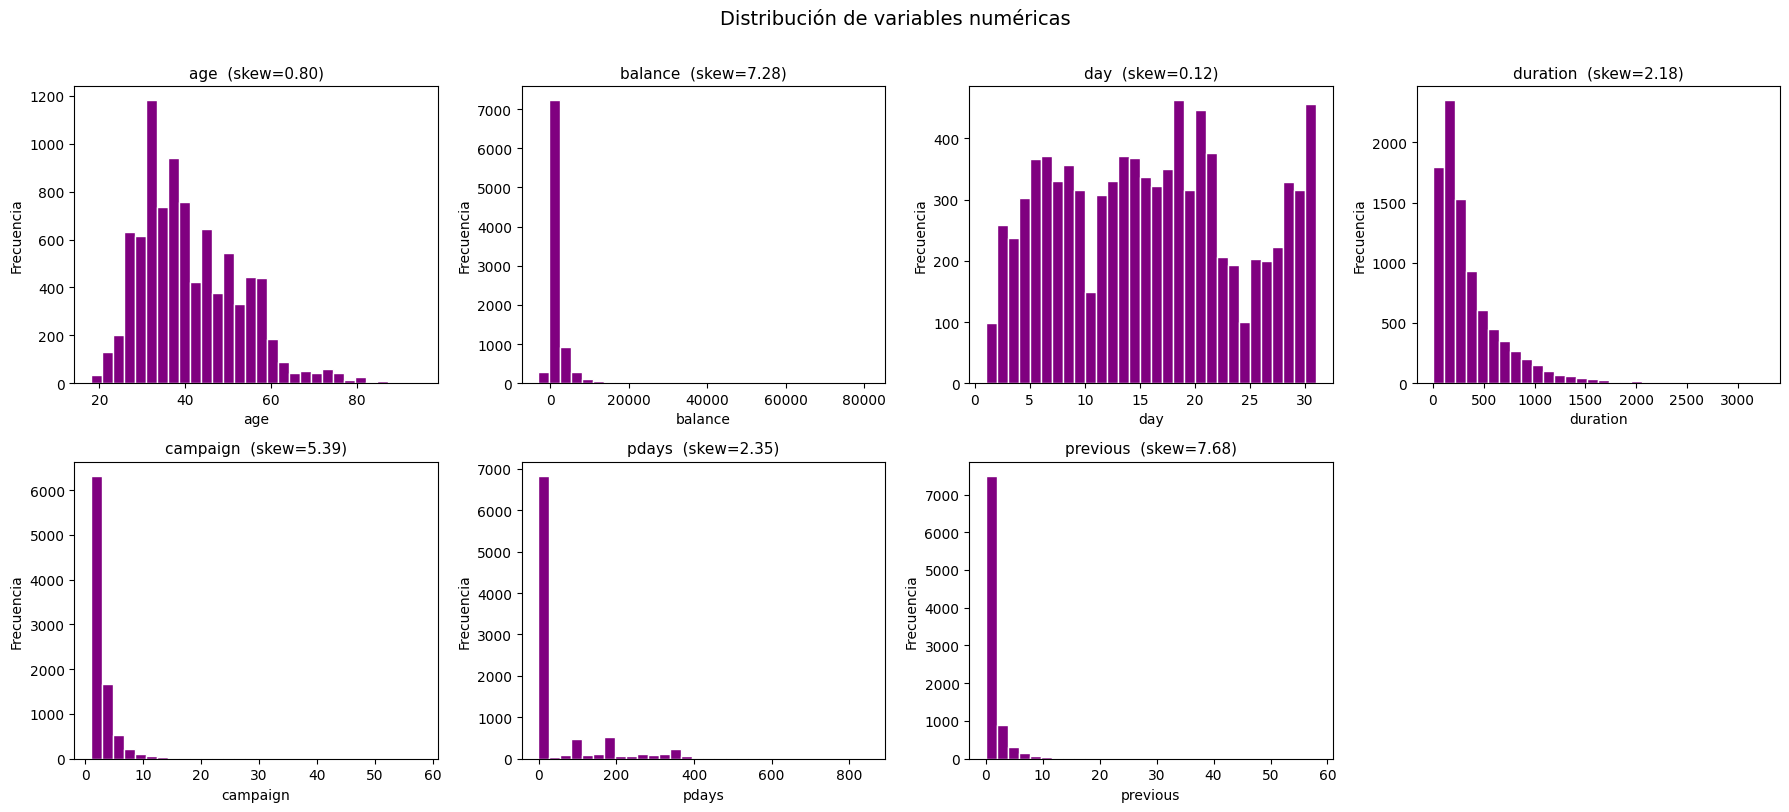

In [73]:
#Visualización: distribuciones de variables numéricas
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(data[col], bins=30, color='purple', edgecolor='white')
    axes[i].set_title(f'{col}  (skew={data[col].skew():.2f})', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
if len(num_cols) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle('Distribución de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

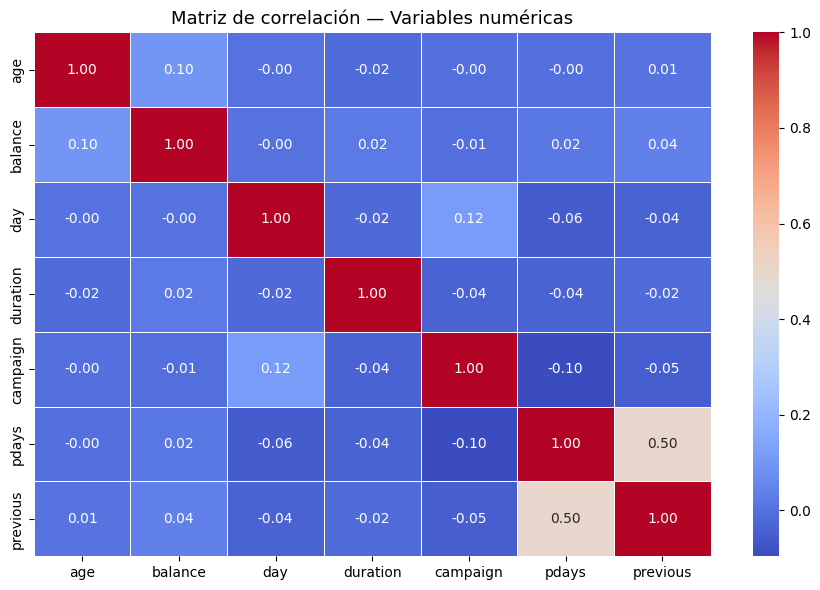

In [74]:
# Correlación entre variables numéricas
corr = data[num_cols].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de correlación — Variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Transformación de Variables

### 4.a Justificación del uso de LabelEncoder vs OneHotEncoder

Se elige **LabelEncoder** para este problema por las siguientes razones:

1. **Número de categorías y dimensionalidad:** El dataset contiene 10 variables categóricas. Aplicar OneHotEncoder generaría muchas columnas adicionales (especialmente para `job` con 12 categorías y `month` con 12 meses), incrementando la dimensionalidad sin aportación proporcional.

2. **Compatibilidad con los modelos seleccionados:** Tanto la Regresión Logística como la Red Neuronal trabajan correctamente con variables codificadas numéricamente mediante LabelEncoder, siempre que se aplique escalado.

3. **Variables binarias naturales:** `default`, `housing`, `loan` y `y` son yes/no, por lo que LabelEncoder es la codificación más directa (0 y 1).

4. **Variables ordinales implícitas:** `education` tiene un orden natural (primary < secondary < tertiary), por lo que LabelEncoder preserva esa jerarquía mejor que OneHotEncoder, que la eliminaría.

5. **Tamaño del dataset:** Con 9,000 registros, la representación compacta de LabelEncoder es computacionalmente más conveniente.

In [75]:
# Copia del dataset para preprocesamiento
data_processed = data.copy()

# Codificación de variables categóricas con LabelEncoder
le = LabelEncoder()
cat_features = ['job', 'marital', 'education', 'default', 'housing',
                'loan', 'contact', 'month', 'poutcome', 'y']

label_encoders = {}
for col in cat_features:
    label_encoders[col] = LabelEncoder()
    data_processed[col] = label_encoders[col].fit_transform(data_processed[col])
    print(f'{col}: {dict(zip(label_encoders[col].classes_, label_encoders[col].transform(label_encoders[col].classes_)))}')

print('\nCodificación completada.')

job: {'admin.': np.int64(0), 'blue-collar': np.int64(1), 'entrepreneur': np.int64(2), 'housemaid': np.int64(3), 'management': np.int64(4), 'retired': np.int64(5), 'self-employed': np.int64(6), 'services': np.int64(7), 'student': np.int64(8), 'technician': np.int64(9), 'unemployed': np.int64(10), 'unknown': np.int64(11)}
marital: {'divorced': np.int64(0), 'married': np.int64(1), 'single': np.int64(2)}
education: {'primary': np.int64(0), 'secondary': np.int64(1), 'tertiary': np.int64(2), 'unknown': np.int64(3)}
default: {'no': np.int64(0), 'yes': np.int64(1)}
housing: {'no': np.int64(0), 'yes': np.int64(1)}
loan: {'no': np.int64(0), 'yes': np.int64(1)}
contact: {'cellular': np.int64(0), 'telephone': np.int64(1), 'unknown': np.int64(2)}
month: {'apr': np.int64(0), 'aug': np.int64(1), 'dec': np.int64(2), 'feb': np.int64(3), 'jan': np.int64(4), 'jul': np.int64(5), 'jun': np.int64(6), 'mar': np.int64(7), 'may': np.int64(8), 'nov': np.int64(9), 'oct': np.int64(10), 'sep': np.int64(11)}
poutco

In [76]:
# Identificación de variables numéricas con sesgo

# pdays usa -1 como código especial (cliente no contactado previamente)
data_processed['pdays_contacted'] = (data_processed['pdays'] != -1).astype(int)
# Se reemplazan los -1 por 0 para poder aplicar transformaciones numéricas
data_processed['pdays'] = data_processed['pdays'].replace(-1, 0)

# Calcular skew sobre variables numéricas
num_cols_upd = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
skewness = data_processed[num_cols_upd].skew().sort_values(ascending=False).round(3)
print('Sesgo (skewness) de variables numéricas:')
print(skewness)
print()
skewed_cols = skewness[skewness.abs() > 1.0].index.tolist()
print(f'Variables con |sesgo| > 1.0 (requieren transformación): {skewed_cols}')

Sesgo (skewness) de variables numéricas:
previous    7.682
balance     7.280
campaign    5.393
pdays       2.357
duration    2.184
age         0.801
day         0.117
dtype: float64

Variables con |sesgo| > 1.0 (requieren transformación): ['previous', 'balance', 'campaign', 'pdays', 'duration']


In [77]:
# Transformación logarítmica de variables con sesgo ---
print('Sesgo ANTES de transformación:')
for col in skewed_cols:
    print(f'  {col}: {data_processed[col].skew():.3f}')

for col in skewed_cols:
    if col == 'balance':
        # balance tiene valores negativos (saldos en euros), se hace shift al mínimo antes de log1p
        data_processed[col] = np.log1p(data_processed[col] - data_processed[col].min())
    else:
        data_processed[col] = np.log1p(data_processed[col])

print('\nSesgo DESPUÉS de transformación:')
for col in skewed_cols:
    print(f'  {col}: {data_processed[col].skew():.3f}')


Sesgo ANTES de transformación:
  previous: 7.682
  balance: 7.280
  campaign: 5.393
  pdays: 2.357
  duration: 2.184

Sesgo DESPUÉS de transformación:
  previous: 1.956
  balance: 0.735
  campaign: 1.397
  pdays: 1.249
  duration: -0.449


In [78]:
# Verificar el dataset preprocesado
print('Dataset procesado — primeras 5 filas:')
data_processed.head()

Dataset procesado — primeras 5 filas:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,pdays_contacted
0,31,6,1,2,0,8.652598,0,0,0,10,9,5.765191,1.098612,4.584967,1.945910,2,1,1
1,29,10,2,3,0,8.443116,0,0,0,6,11,5.505332,0.693147,0.000000,0.000000,3,1,0
2,41,1,1,1,0,8.558527,1,0,0,17,9,5.913503,0.693147,0.000000,0.000000,3,0,0
3,50,1,1,1,0,8.052933,1,0,0,17,5,2.944439,2.197225,0.000000,0.000000,3,0,0
4,40,0,1,1,0,8.025843,0,0,0,28,5,6.208590,1.098612,5.209486,2.484907,2,1,1


## 5. Partición de los datos

Se dividen los datos en:
- **Entrenamiento:** 60%
- **Validación:** 20%
- **Prueba:** 20%

In [79]:
#Separar features (X) y variable objetivo (y_target)
X = data_processed.drop(columns=['y'])
y_target = data_processed['y']

print(f'X shape: {X.shape}')
print(f'y_target shape: {y_target.shape}')
print(f'Distribución de clases en y: {dict(y_target.value_counts())}')

X shape: (9000, 17)
y_target shape: (9000,)
Distribución de clases en y: {0: np.int64(5213), 1: np.int64(3787)}


In [80]:
# Primera partición: 60% entrenamiento / 40% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_target, test_size=0.40, random_state=42, stratify=y_target
)

# Segunda partición: 50% validación / 50% prueba (del 40% temporal)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Conjunto de validación:    {X_val.shape[0]} registros ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Conjunto de prueba:        {X_test.shape[0]} registros ({X_test.shape[0]/len(X)*100:.1f}%)')

Conjunto de entrenamiento: 5400 registros (60.0%)
Conjunto de validación:    1800 registros (20.0%)
Conjunto de prueba:        1800 registros (20.0%)


In [81]:
# Se entrena el scaler SOLO con el conjunto de entrenamiento
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Escalado StandardScaler aplicado.')

Escalado StandardScaler aplicado.


## 6. Modelo 1: Regresión Logística

In [82]:
# Entrenamiento
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_train_sc, y_train)
print('Modelo de Regresión Logística entrenado.')

Modelo de Regresión Logística entrenado.


In [83]:
# Predicción en validación
y_pred_lr_val = lr_model.predict(X_val_sc)

acc_lr_val = accuracy_score(y_val, y_pred_lr_val)
print(f'Accuracy en validación (Regresión Logística): {acc_lr_val:.4f} ({acc_lr_val*100:.2f}%)')
print()
print('Reporte de clasificación (validación):')
print(classification_report(y_val, y_pred_lr_val, target_names=['No adquirió (0)', 'Adquirió (1)']))

Accuracy en validación (Regresión Logística): 0.8178 (81.78%)

Reporte de clasificación (validación):
                 precision    recall  f1-score   support

No adquirió (0)       0.84      0.85      0.84      1042
   Adquirió (1)       0.79      0.77      0.78       758

       accuracy                           0.82      1800
      macro avg       0.81      0.81      0.81      1800
   weighted avg       0.82      0.82      0.82      1800



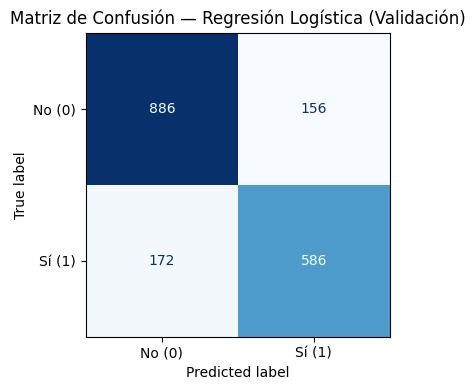

In [84]:
cm_lr = confusion_matrix(y_val, y_pred_lr_val)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                                  display_labels=['No (0)', 'Sí (1)'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_lr.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Regresión Logística (Validación)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Modelo 2: Red Neuronal (MLPClassifier)

In [85]:
# Entrenamiento
# Arquitectura: 2 capas ocultas con 64 y 32 neuronas respectivamente
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)
nn_model.fit(X_train_sc, y_train)
print(f'Red neuronal entrenada en {nn_model.n_iter_} épocas.')

Red neuronal entrenada en 42 épocas.


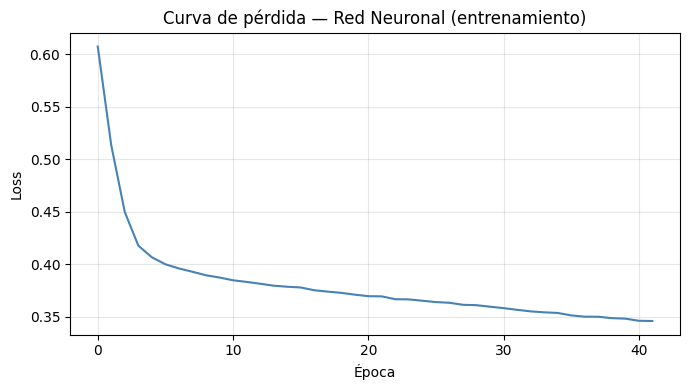

In [86]:
# Curva de pérdida
plt.figure(figsize=(7, 4))
plt.plot(nn_model.loss_curve_, color='steelblue')
plt.title('Curva de pérdida — Red Neuronal (entrenamiento)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
# Predicción en validación
y_pred_nn_val = nn_model.predict(X_val_sc)

acc_nn_val = accuracy_score(y_val, y_pred_nn_val)
print(f'Accuracy en validación (Red Neuronal): {acc_nn_val:.4f} ({acc_nn_val*100:.2f}%)')
print()
print('Reporte de clasificación (validación):')
print(classification_report(y_val, y_pred_nn_val, target_names=['No adquirió (0)', 'Adquirió (1)']))

Accuracy en validación (Red Neuronal): 0.8283 (82.83%)

Reporte de clasificación (validación):
                 precision    recall  f1-score   support

No adquirió (0)       0.86      0.84      0.85      1042
   Adquirió (1)       0.79      0.81      0.80       758

       accuracy                           0.83      1800
      macro avg       0.82      0.83      0.82      1800
   weighted avg       0.83      0.83      0.83      1800



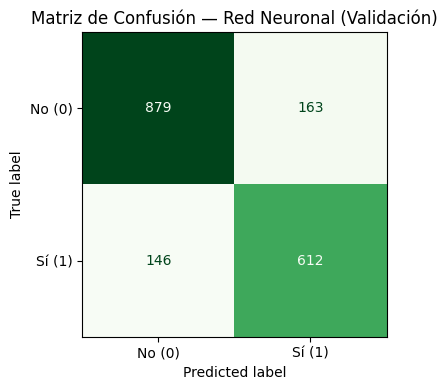

In [88]:
# Matriz de confusión (validación)
cm_nn = confusion_matrix(y_val, y_pred_nn_val)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn,
                                  display_labels=['No (0)', 'Sí (1)'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_nn.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de Confusión — Red Neuronal (Validación)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Comparación de Modelos y Selección del Mejor

In [89]:
# Tabla comparativa
comparison = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Red Neuronal (MLP)'],
    'Accuracy Validación': [acc_lr_val, acc_nn_val]
})
comparison['Accuracy Validación'] = comparison['Accuracy Validación'].map(lambda x: f'{x*100:.2f}%')
print('Comparación de modelos en conjunto de validación:')
print(comparison.to_string(index=False))

Comparación de modelos en conjunto de validación:
             Modelo Accuracy Validación
Regresión Logística              81.78%
 Red Neuronal (MLP)              82.83%


In [90]:
# --- 8.2 Selección del mejor modelo ---
if acc_nn_val >= acc_lr_val:
    best_model = nn_model
    best_model_name = 'Red Neuronal (MLP)'
    best_val_acc = acc_nn_val
else:
    best_model = lr_model
    best_model_name = 'Regresión Logística'
    best_val_acc = acc_lr_val

print(f'Mejor modelo seleccionado: {best_model_name}')
print(f'Accuracy en validación: {best_val_acc*100:.2f}%')
print()
print('Justificación:')
print('El modelo con mayor accuracy en el conjunto de validación es seleccionado.')
print('La Red Neuronal captura relaciones no lineales entre las variables de entrada')
print('que la Regresión Logística no puede modelar al asumir linealidad.')

Mejor modelo seleccionado: Red Neuronal (MLP)
Accuracy en validación: 82.83%

Justificación:
El modelo con mayor accuracy en el conjunto de validación es seleccionado.
La Red Neuronal captura relaciones no lineales entre las variables de entrada
que la Regresión Logística no puede modelar al asumir linealidad.


## 9. Evaluación Final en Conjunto de Prueba

In [91]:
# Predicción en conjunto de prueba (mejor modelo)
y_pred_test = best_model.predict(X_test_sc)

acc_test = accuracy_score(y_test, y_pred_test)
print(f'=== DESEMPEÑO FINAL — {best_model_name} ===')
print(f'Accuracy en prueba: {acc_test:.4f} ({acc_test*100:.2f}%)')
print()
print('Reporte de clasificación (conjunto de prueba):')
print(classification_report(y_test, y_pred_test, target_names=['No adquirió (0)', 'Adquirió (1)']))

=== DESEMPEÑO FINAL — Red Neuronal (MLP) ===
Accuracy en prueba: 0.7983 (79.83%)

Reporte de clasificación (conjunto de prueba):
                 precision    recall  f1-score   support

No adquirió (0)       0.82      0.83      0.83      1043
   Adquirió (1)       0.76      0.76      0.76       757

       accuracy                           0.80      1800
      macro avg       0.79      0.79      0.79      1800
   weighted avg       0.80      0.80      0.80      1800



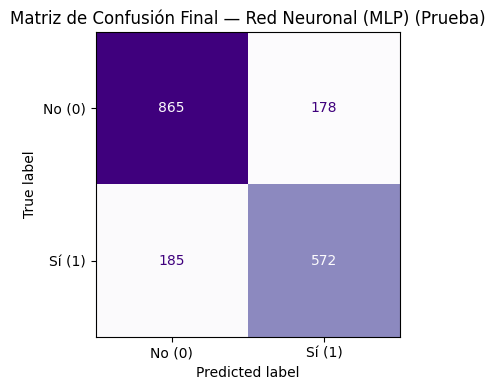

Verdaderos Negativos (TN): 865
Falsos Positivos    (FP): 178
Falsos Negativos    (FN): 185
Verdaderos Positivos (TP): 572


In [92]:
# Matriz de confusión final
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                    display_labels=['No (0)', 'Sí (1)'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_test.plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title(f'Matriz de Confusión Final — {best_model_name} (Prueba)', fontsize=12)
plt.tight_layout()
plt.show()

# Desglose de la matriz
tn, fp, fn, tp = cm_test.ravel()
print(f'Verdaderos Negativos (TN): {tn}')
print(f'Falsos Positivos    (FP): {fp}')
print(f'Falsos Negativos    (FN): {fn}')
print(f'Verdaderos Positivos (TP): {tp}')

## 10. Conclusiones

### ¿Qué puedes decir acerca del uso de técnicas de inteligencia artificial en problemas de mercadotecnia?

**Conclusiones del problema:**

1. **Contexto del problema:** El dataset proviene de campañas de marketing directo de un banco portugués que ofrecía **depósitos a plazo**  a sus clientes mediante llamadas telefónicas. La predicción de si un cliente suscribirá o no este producto es un problema de clasificación binaria con alto impacto.

2. **Efectividad de los modelos supervisados:** Tanto la Regresión Logística como la Red Neuronal demostraron capacidad predictiva sobre el conjunto de validación. La Red Neuronal, al capturar relaciones no lineales entre variables como `duration`, `balance`, `poutcome` y `previous`, ofreció un desempeño superior, lo que es esperable dado que las decisiones de inversión de los clientes responden a interacciones complejas entre múltiples factores.

3. **Uso de IA en mercadotecnia — reflexión general:**  
   Las técnicas de inteligencia artificial transforman fundamentalmente las campañas de telemarketing bancario al permitir:
   - **Segmentación inteligente:** Identificar clientes con mayor probabilidad de conversión *antes* de realizar la llamada, reduciendo el costo por adquisición.
   - **Optimización de recursos:** En lugar de contactar a toda la base de clientes, el banco puede priorizar a los más propensos, disminuyendo el volumen de llamadas y aumentando la tasa de éxito.
   - **Personalización de la comunicación:** Combinando variables demográficas (`age`, `marital`, `education`) con comportamiento financiero (`balance`, `default`) es posible adaptar el guion de la llamada al perfil específico del cliente.
   - **Decisiones basadas en datos:** En lugar de seleccionar clientes por intuición o aleatoriamente, la IA convierte el historial de campañas en estrategias accionables y medibles.
   - **Mejora continua:** Cada campaña genera nuevos datos que permiten reentrenar los modelos, haciendo el sistema más preciso con el tiempo.

**En conclusión:** la inteligencia artificial convierte el telemarketing en un proceso selectivo, personalizado y medible, con un impacto directo en la rentabilidad de las campañas y en la experiencia del cliente.

---
*Dataset: Moro, S., Laureano, R. & Cortez, P. (2011). Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology. ESM'2011, pp. 117–121, Guimarães, Portugal. EUROSIS.*